# Patch Motion Matching (KITTI)

Match local patches across **consecutive frames** and visualize:
1. Source frame with patch grid + motion arrows
2. Zoom gallery: patch at $t$ | matched patch at $t{+}1$ | residual

**Sequence:** KITTI tracking `0019` under `Research_Data/data_tracking_image_2/`.

## Single-patch diagnostic (2 frames)

What the algorithm does for **one** patch:
1. Cut input patch from frame 1 around a center `(y, x)`
2. Cut a **search window** in frame 2 around the same center
3. Slide the patch over the window, compute a matching **cost** at each offset (SSD / SAD / NCC)
4. Best match = lowest cost → displacement `(dx, dy)`

Below: frames with boxes, cost map, and pixel charts (mid-row + scatter).

Δ=(dx,dy)=(-4.0, -1.0)  SSD=5.0859  cost_map=(33, 33)


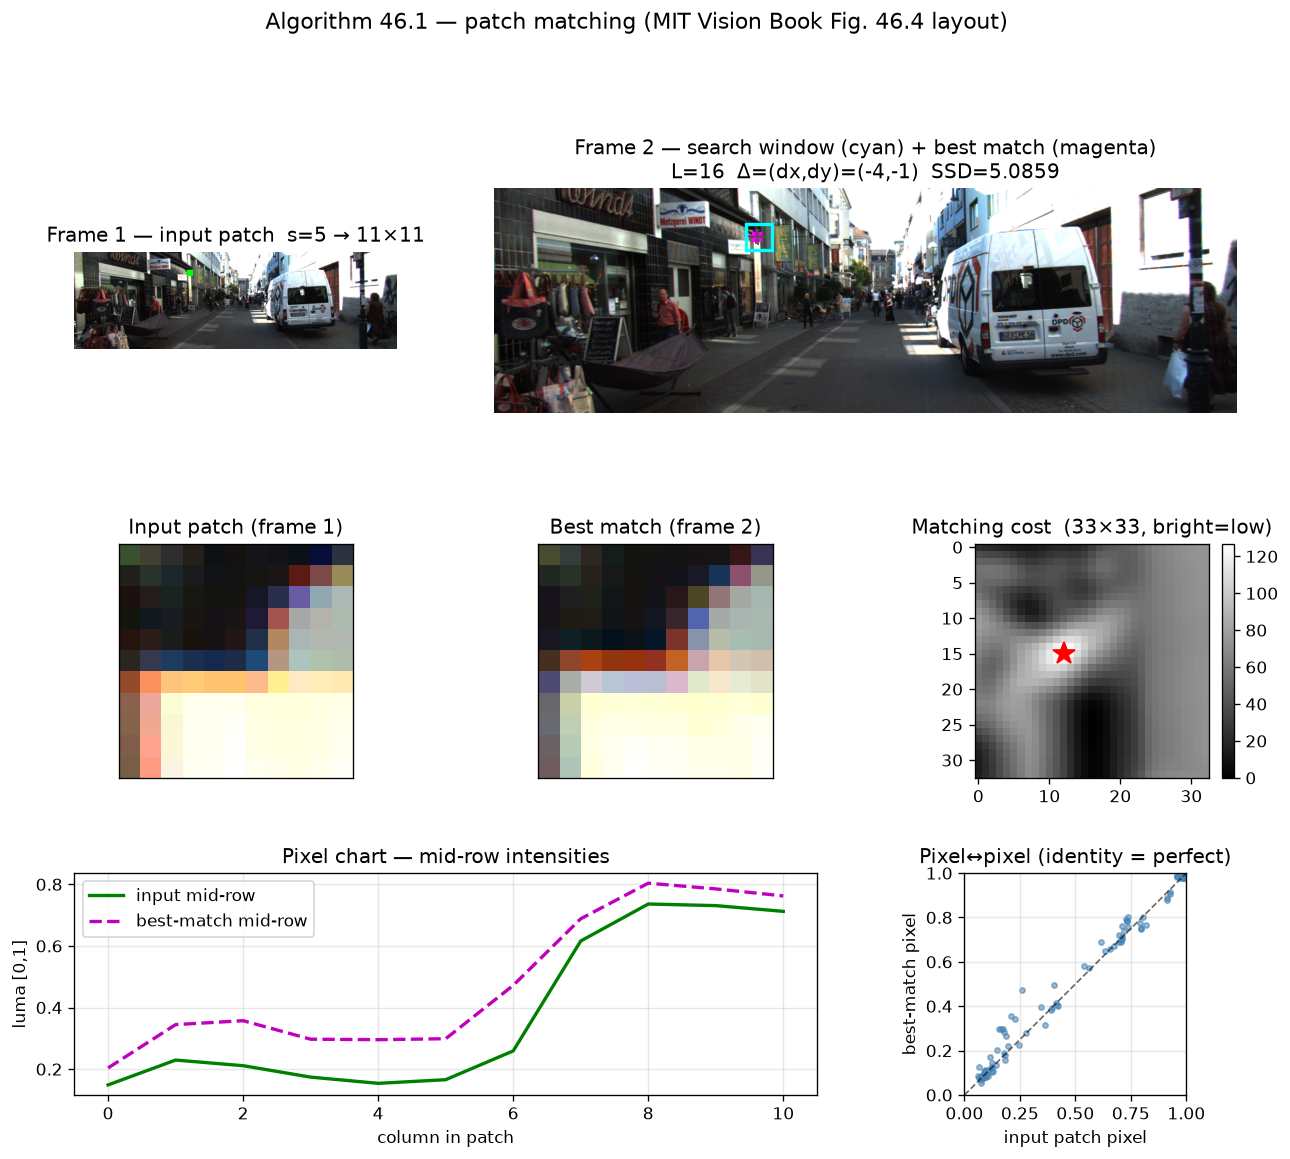

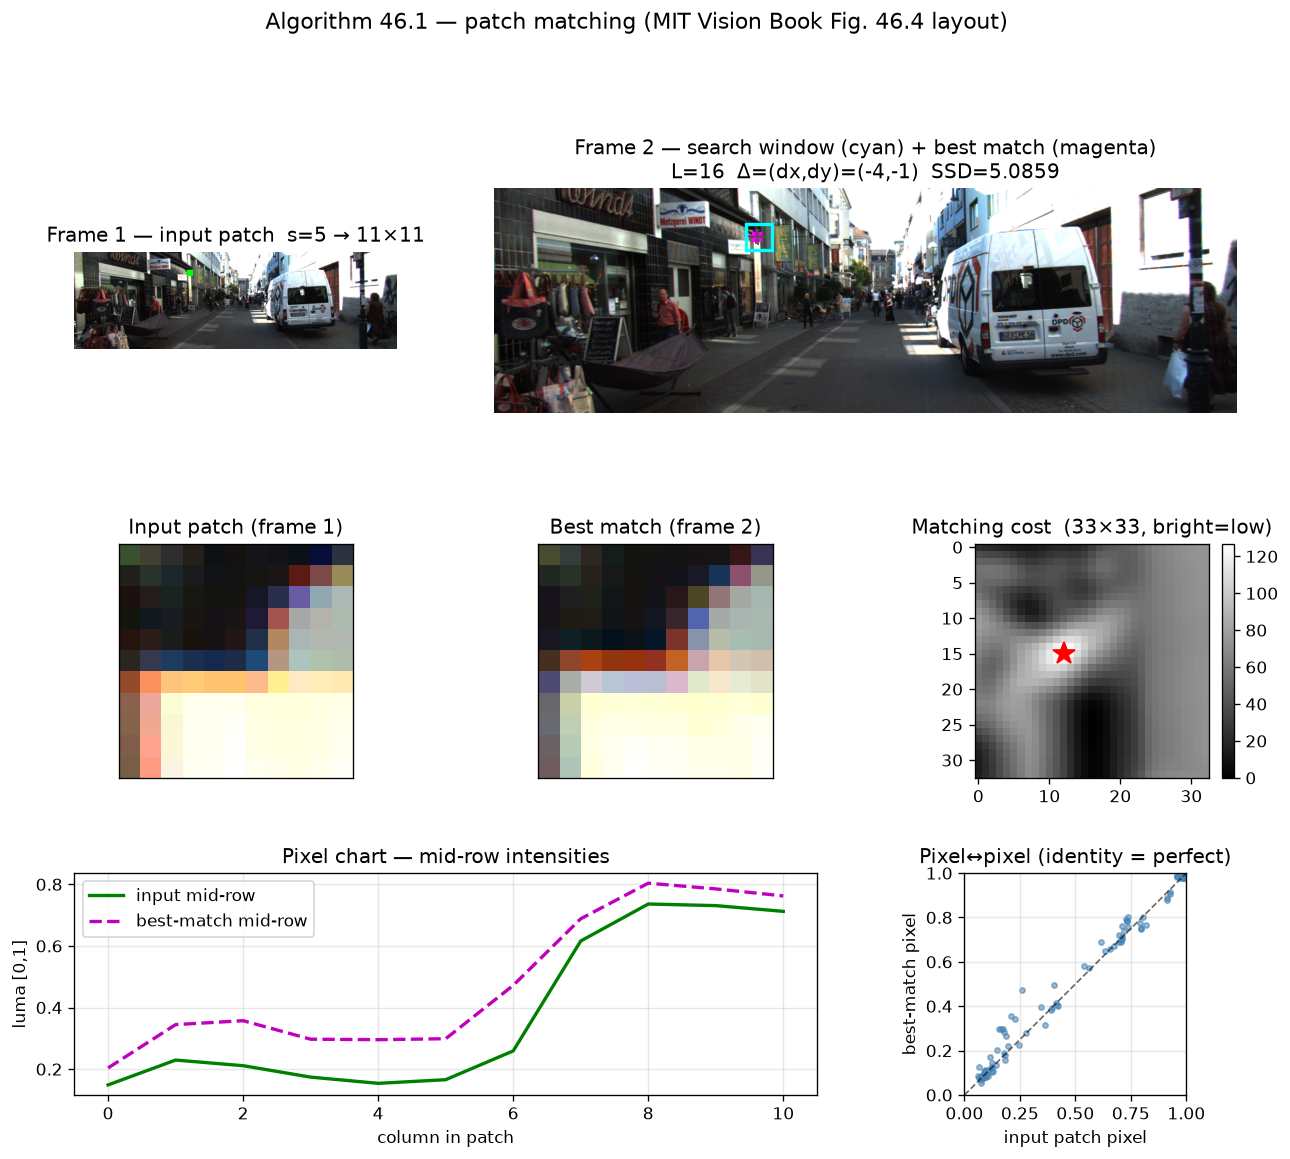

In [8]:
# Algorithm 46.1 (MIT Vision Book): one patch, book params s=5, L=16
from pathlib import Path
from patch_motion_matching import (
    default_kitti_seq, list_kitti_frames, load_rgb,
    match_single_patch, visualize_single_patch_match,
)

frames = list_kitti_frames(default_kitti_seq(seq="0019"))
rgb1, rgb2 = load_rgb(frames[120]), load_rgb(frames[121])
f1 = rgb1.astype("float32") / 255.0
f2 = rgb2.astype("float32") / 255.0

# textured interior match (not stuck on ±L boundary)
center = (80, 440)
res = match_single_patch(
    f1, f2, center,
    patch_size=11,      # s=5  → (2s+1)
    search_radius=16,   # L=16 → cost map (2L+1)×(2L+1) = 33×33
    metric="ssd",       # Euclidean / SSD = book dist()
)
print(f"Δ=(dx,dy)={res.displacement_xy}  SSD={res.cost:.4f}  cost_map={res.cost_map.shape}")

fig = visualize_single_patch_match(rgb1, rgb2, res)
out = Path("../outputs/analysis/patch_match_algorithm46_1.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=140, bbox_inches="tight")
fig
